Loading Training Data...
Training XGBoost Model...
Model Accuracy on Kolkata Test Data:
  - Mean Absolute Error: 22.36 µg/m³
  - Root Mean Squared Error: 29.26 µg/m³

Generating Predictions for IIT Guwahati...
Success! Predictions saved to Predicted_PM25_IIT_Guwahati_2025.csv


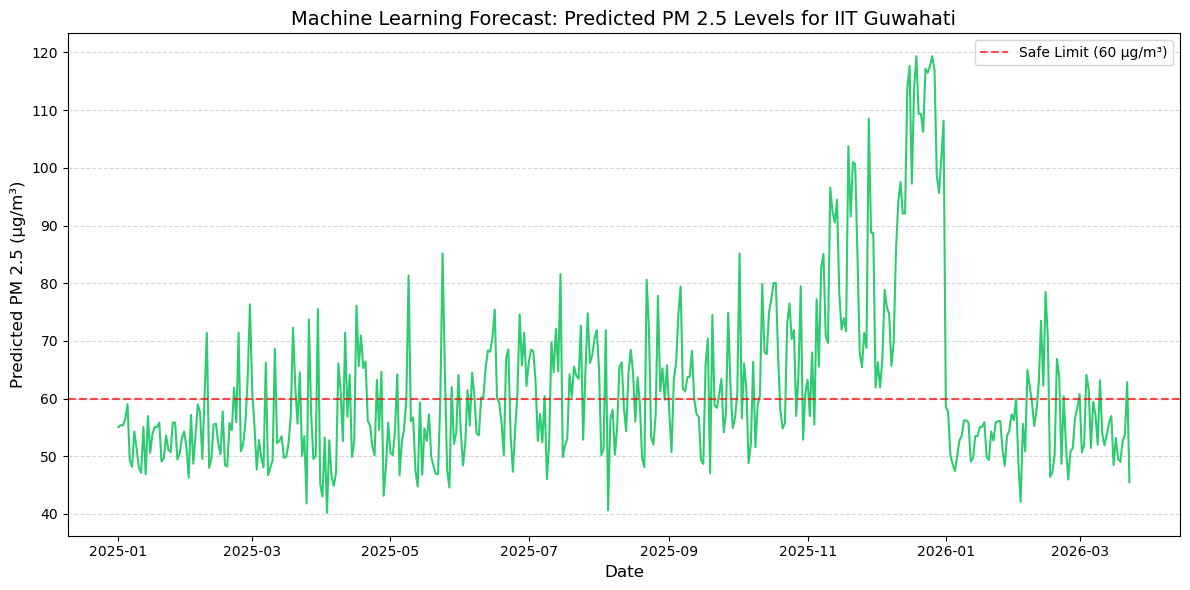

In [2]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# STEP 1: PREPARE THE TRAINING DATA (KOLKATA)
# ==========================================
print("Loading Training Data...")

# Load the flattened features for Kolkata
train_features = pd.read_csv("XGBoost_Ready_Kolkata_JU_Dataset.csv")

# Load the historical PM 2.5 targets for Kolkata 
train_targets = pd.read_csv("Processed_Daily_PM25_Kolkata_ju_2025.csv") 

# Merge them together based on the date
train_features['Date_Str'] = train_features['Date_Str'].astype(str)
train_targets['Date'] = pd.to_datetime(train_targets['Date']).astype(str)

training_data = pd.merge(train_features, train_targets, left_on='Date_Str', right_on='Date', how='inner')

# Define what our inputs (X) and output (y) are
# Drop the text/date columns since XGBoost only understands numbers
X = training_data.drop(columns=['Date_Str', 'Date', 'PM2.5'])
y = training_data['PM2.5']

# Split the Kolkata data (80% for training, 20% for internal testing/validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# ==========================================
# STEP 2: TRAIN THE XGBOOST MODEL
# ==========================================
print("Training XGBoost Model...")

# Initialize the XGBoost Regressor
# NOTE: early_stopping_rounds is placed here for newer versions of XGBoost
model = xgb.XGBRegressor(
    n_estimators=500,        # Number of decision trees
    learning_rate=0.05,      # How aggressively the model learns
    max_depth=6,             # Maximum depth of each tree
    subsample=0.8,           # Use 80% of rows per tree to prevent overfitting
    colsample_bytree=0.8,    # Use 80% of columns per tree
    random_state=42,
    early_stopping_rounds=50 # Stop early if accuracy stops improving
)

# Train the model
model.fit(X_train, y_train, 
          eval_set=[(X_test, y_test)], 
          verbose=False)

# Check how well it learned Kolkata's pollution patterns
predictions_test = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions_test))
mae = mean_absolute_error(y_test, predictions_test)
print(f"Model Accuracy on Kolkata Test Data:\n  - Mean Absolute Error: {mae:.2f} µg/m³\n  - Root Mean Squared Error: {rmse:.2f} µg/m³\n")


# ==========================================
# STEP 3: PREDICT FOR IIT GUWAHATI
# ==========================================
print("Generating Predictions for IIT Guwahati...")

# Load IIT Guwahati's features
predict_features = pd.read_csv("XGBoost_Ready_IITG_Dataset.csv")

# Save the dates so we can re-attach them to the predictions later
iitg_dates = predict_features['Date_Str']

# Drop the date string column so the format exactly matches our training data (X)
X_predict = predict_features.drop(columns=['Date_Str'])

# Make the prediction!
iitg_predictions = model.predict(X_predict)

# Create a final dataframe with the Dates and the Predicted PM 2.5
final_predictions = pd.DataFrame({
    'Date': iitg_dates,
    'Predicted_PM2.5': np.round(iitg_predictions, 2)
})

# Save to CSV
output_file = "Predicted_PM25_IIT_Guwahati_2025.csv"
final_predictions.to_csv(output_file, index=False)
print(f"Success! Predictions saved to {output_file}")


# ==========================================
# STEP 4: VISUALIZE THE PREDICTIONS
# ==========================================
# Convert Date to actual datetime for smooth plotting
final_predictions['Date'] = pd.to_datetime(final_predictions['Date'])

plt.figure(figsize=(12, 6))
plt.plot(final_predictions['Date'], final_predictions['Predicted_PM2.5'], color='#2ecc71', linewidth=1.5)
plt.title('Machine Learning Forecast: Predicted PM 2.5 Levels for IIT Guwahati', fontsize=14)
plt.ylabel('Predicted PM 2.5 (µg/m³)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.axhline(60, color='red', linestyle='--', alpha=0.7, label='Safe Limit (60 µg/m³)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("IITG_PM25_Prediction_Plot.png")
plt.show()